### Imports and Setup

[ WARN:0@135000.748] global loadsave.cpp:268 findDecoder imread_('../data/marker_masks/-LeGr5GgY30JbjHXHI69.-LeGrASzOiaSf8oHM-pF.-LeGrt6CF6EZBfcZFwqY.png'): can't open/read file: check file path/integrity


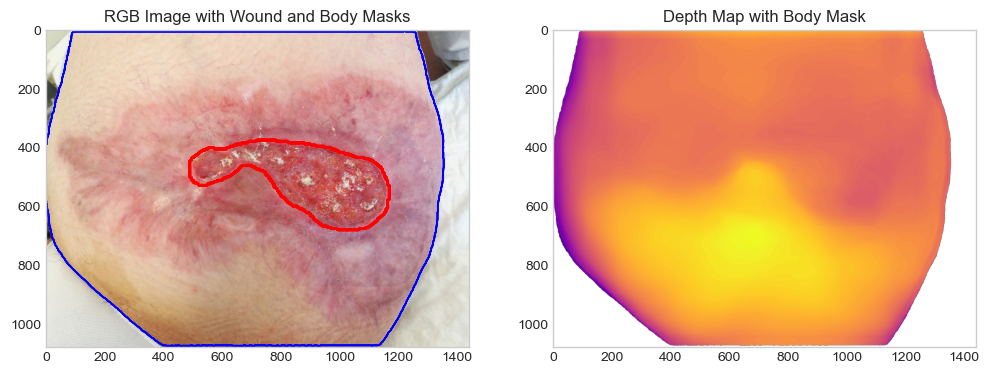

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
from scipy.optimize import curve_fit

# Set plot style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')

#sample image names

image_id = ['-Lc_d-g4yyU44NLZYjLv.-Lc_dR6iUjsYfyL3NJc5.-Lc_dxMn-GvgO7lEfgfE',
            '-LcfARU6yMZ2m2s6CoLf.-LhiLyo332AVoAFcUndg.-LoU0rVOOmA1bDIx3zLF',
            '-LeGr5GgY30JbjHXHI69.-LeGrASzOiaSf8oHM-pF.-LeGrt6CF6EZBfcZFwqY',
            '-Leujocx_cjh-Ci6MrBu.-NLUo7sNx6hp4uSLWSwI.-NQ-6HHv1xoKIDy48blM',
            '-LcjI5OGPRxeAj_JwEb0.-LcjISTwgjaAZF_xYXxT.-LjFh4DROm9CaNMN6ic9',
            '-N3TKnmASS39_DJZaHma.-N3TNrRY-7i9dZsKTiNn.-NiZ5C4oQu0AO2-_l9Ht']
name = image_id[5]

DATA_PATH = f'../data'

IMAGE_PATH = f'{DATA_PATH}/images/{name}.png'
WOUND_MASK_PATH = f'{DATA_PATH}/wound_masks/{name}.png'
BODY_MASK_PATH = f'{DATA_PATH}/body_masks/{name}.png'
MARKER_MASK_PATH = f'{DATA_PATH}/marker_masks/{name}.png'
DEPTH_MAP_PATH = f'{DATA_PATH}/depth_maps/{name}.png'


image = cv2.imread(IMAGE_PATH)[..., ::-1]
wound = cv2.imread(WOUND_MASK_PATH, cv2.IMREAD_GRAYSCALE)
body = cv2.imread(BODY_MASK_PATH, cv2.IMREAD_GRAYSCALE)
depth= cv2.imread(DEPTH_MAP_PATH, cv2.IMREAD_ANYDEPTH)
marker = cv2.imread(MARKER_MASK_PATH, cv2.IMREAD_GRAYSCALE)

depth = cv2.bitwise_and(depth, depth, mask=body)

if not marker is None:
    depath = cv2.bitwise_and(depth, depth, mask=~marker)
    body = cv2.bitwise_and(body, body, mask=~marker)


fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(image)
ax1.grid(False) # <--- Explicitly turn off grid
ax1.contour(wound, colors='red', linewidths=2)
ax1.contour(body, colors='blue', linewidths=1)
ax1.set_title("RGB Image with Wound and Body Masks")

ax2.imshow(np.where(depth != 0, depth, np.nan), cmap='plasma_r')
ax2.set_title("Depth Map with Body Mask")
ax2.grid(False) # <--- Explicitly turn off grid

### Depth Map Correction

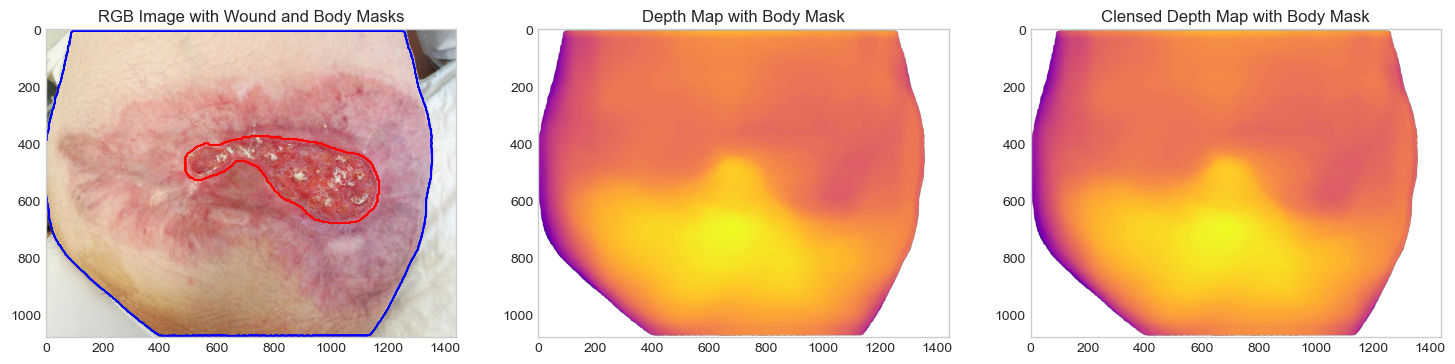

In [75]:
# clensing depth map by removing any artifacts if there are any
# the erroneous pixels are determined by using the Z-score method

# Calculate Z-score for depth values
z_score = (depth - depth.mean())/ depth.std()

# Set a threshold for Z-score (here use 2) to identify outliers
body_clensed = body.copy()
body_clensed[(z_score < -2) | (z_score > 2)] = 0

# clesning the depth map using the body mask already clensed
depth_clensed = cv2.bitwise_and(depth, depth, mask=body_clensed)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
ax1.imshow(image)
ax1.grid(False) # <--- Explicitly turn off grid
ax1.contour(wound, colors='red', linewidths=1)
ax1.contour(body, colors='blue', linewidths=1)
ax1.set_title("RGB Image with Wound and Body Masks")
ax2.imshow(np.where(depth != 0, depth, np.nan), cmap='plasma_r')
ax2.grid(False) # <--- Explicitly turn off grid
ax2.set_title("Depth Map with Body Mask")
ax3.imshow(np.where(depth_clensed != 0, depth_clensed, np.nan), cmap='plasma_r')
ax3.set_title("Clensed Depth Map with Body Mask")
ax3.grid(False) # <--- Explicitly turn off grid


#### Depth Map Correction by Removing body curvature

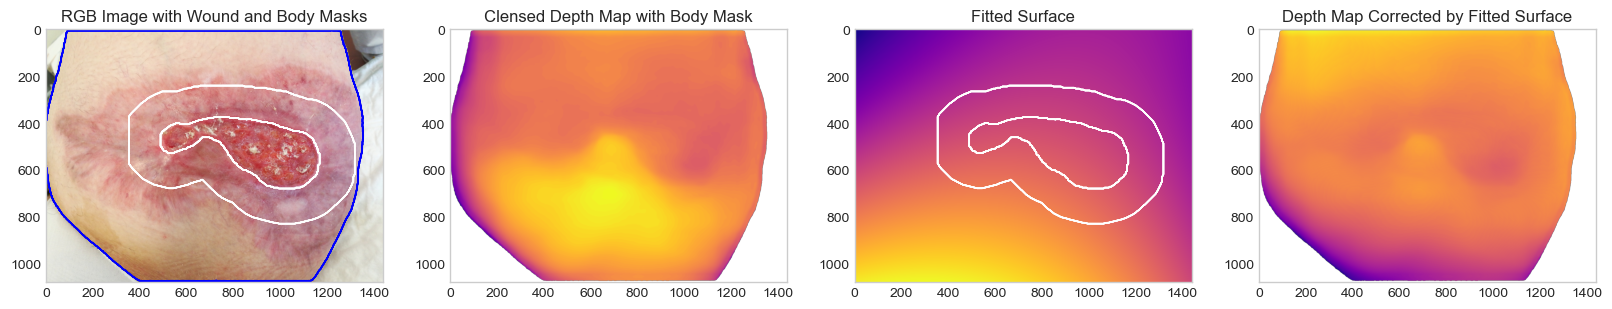

In [76]:
def function(xy, a, b, c, d, e, g):
    x, y = xy
    return a*x**2 + b*y**2 + c*x*y + d*x + e*y + g

kernel = cv2.getStructuringElement(shape = cv2.MORPH_ELLIPSE, ksize = (20, 20))

dilated_wound = cv2.dilate(wound, kernel = kernel, iterations=15)

dilated_wound = dilated_wound - wound

dilated_wound = cv2.bitwise_and(dilated_wound, dilated_wound, mask=body_clensed)    

depth_dilated = np.where(dilated_wound == 0, 0, depth_clensed)

x, y = np.nonzero(depth_dilated)
z = depth_dilated[depth_dilated != 0]
# Fit the polynomial surface to the depth data
popt, pcov = curve_fit(function, xdata = (x, y), ydata = z)

# Create a grid for the fitted surface
h, w = depth.shape
y, x = np.mgrid[0:h, 0:w]
# Calculate the fitted surface
fitted_surface = function((y, x), *popt)
depth_corrected = depth_clensed - fitted_surface
depth_corrected = cv2.bitwise_and(depth_corrected, depth_corrected, mask=body_clensed)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 5))
ax1.imshow(image)
ax1.grid(False) # <--- Explicitly turn off grid
ax1.contour(dilated_wound, colors='white', linewidths=1)
ax1.contour(body, colors='blue', linewidths=1)

ax1.set_title("RGB Image with Wound and Body Masks")
ax2.imshow(np.where(depth_clensed != 0, depth_clensed, np.nan), cmap='plasma_r')
ax2.grid(False) # <--- Explicitly turn off grid
ax2.set_title("Clensed Depth Map with Body Mask")
ax3.imshow(fitted_surface, cmap='plasma_r')
ax3.contour(dilated_wound, colors='white', linewidths=1)
ax3.set_title("Fitted Surface")
ax3.grid(False) # <--- Explicitly turn off grid
ax4.imshow(np.where(depth_corrected != 0, depth_corrected, np.nan), cmap='plasma_r')
ax4.set_title("Depth Map Corrected by Fitted Surface")
ax4.grid(False) # <--- Explicitly turn off grid  


### Declaration of Peri-Wound Area - Debugging

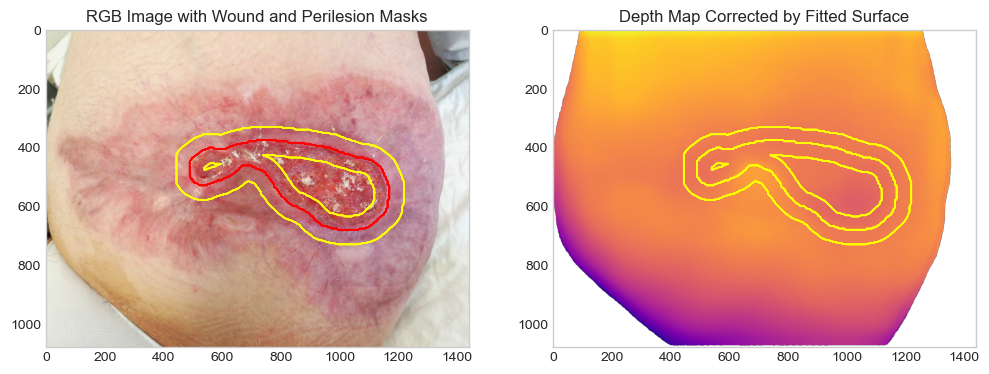

In [77]:
kernel = cv2.getStructuringElement(shape = cv2.MORPH_ELLIPSE, ksize = (20, 20))

dilation = cv2.dilate(wound, kernel = kernel, iterations=5)

erosion = cv2.erode(wound, kernel = kernel, iterations=5)

perilesion_mask = cv2.subtract(dilation, erosion)

peri_wound = cv2.bitwise_and(perilesion_mask, perilesion_mask, mask=body_clensed)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
ax1.imshow(image)
ax1.grid(False) # <--- Explicitly turn off grid
ax1.contour(wound, colors='red', linewidths=1)
ax1.contour(peri_wound, colors='yellow', linewidths=1)
ax1.set_title("RGB Image with Wound and Perilesion Masks")

ax2.imshow(np.where(depth_corrected != 0, depth_corrected, np.nan), cmap='plasma_r')
ax2.contour(wound, colors='yellow', linewidths=1)
ax2.contour(peri_wound, colors='yellow', linewidths=1)
ax2.set_title("Depth Map Corrected by Fitted Surface")
ax2.grid(False) # <--- Explicitly turn off grid


### Peri-Wound Rectification - Border Strip

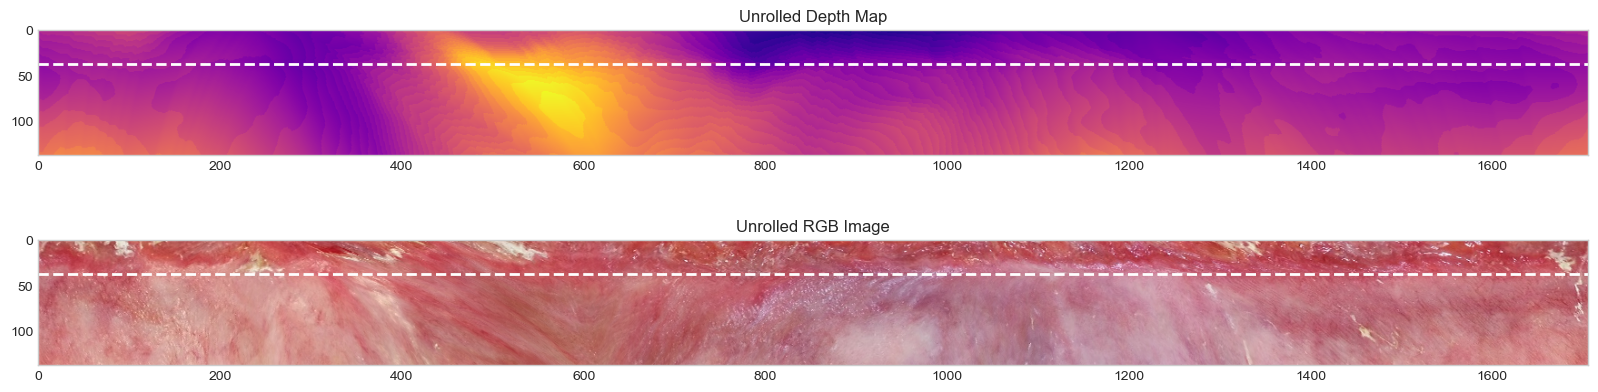

In [78]:
def sample_pixels_from_contour(img, mask):
    # Getting the contours of the mask
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    
    # Getting the longest contour for the safety 
    # And removes unnecessary, single-dimension entries from the contour array's shape.
    contour = np.squeeze(max(contours, key=len))
    
    # Swapping height and width axes of the image to match the contour's shape. 
    # Image is in HWC format, while contour is in WH format.
    pixs = np.swapaxes(img, axis1=0, axis2=1)
    
    # Sampling pixels from the image using the contour coordinates
    # The contour is a 2D array of coordinates, so we use tuple to index {transpose the array and convert to tuple, 
    # two separate 1D arrays for x and y coordinates}
    pixs = pixs[tuple(contour.T)]
    
    # Expanding the dimensions to match the expected shape: like matrix of pixels
    pixs = np.expand_dims(pixs, axis=1)
    
    return pixs

def unroll_periwound_to_image(img, mask, iterations : int = 1):
    # getting the base strip of pixels from the contour
    pixl1 = sample_pixels_from_contour(img, mask)
    
    # getting the shape of the base strip
    h, w, *_ = pixl1.shape

    # initializing the list of dilations from the base strip
    dilations = [pixl1]

    # defining the 3x3 elliptical kernel for dilation
    kernel = cv2.getStructuringElement(shape = cv2.MORPH_ELLIPSE, ksize = (3, 3)) 

    temp_msk = mask.copy()
    Ndilations = 1

    for i in range(iterations):
        # dilating the mask
        temp_msk = cv2.dilate(temp_msk, kernel, iterations=1)

        # getting the pixels from the dilated mask
        pixl2 = sample_pixels_from_contour(img, temp_msk)
        
        # checking if the plexels are empty
        # if the dilation breaks the mask into several parts, we stop the process
        if pixl2 is None: break
        
        # resizing the pixels to the original shape
        # because the dilation may change the shape of the mask
        pixl2 = cv2.resize(pixl2, (w, h), interpolation=cv2.INTER_CUBIC)
        
        # appending the dilated pixels to the base strip 
        dilations.append(pixl2)
        
    num_dilations = len(dilations)

    temp_msk = mask.copy()
    erosions = []
    num_erostions = 1

    for i in range(iterations):
        # eroding the mask
        temp_msk = cv2.erode(temp_msk, kernel, iterations=1)

        # checking wheather the erosion breaks the mask into several parts
        # originally there are 2 components background and the mask
        num_components, _ = cv2.connectedComponents(temp_msk)
        if num_components > 2:
            # if the erosion breaks the mask into several parts, we stop the process
            break
        
        # getting the pixels from the eroded mask
        pixl2 = sample_pixels_from_contour(img, temp_msk)

        # resizing the pixels to the original shape
        # because the erosion may change the shape of the mask
        pixl2 = cv2.resize(pixl2, (w, h), interpolation=cv2.INTER_CUBIC)

        # appending the eroded pixels to the base strip
        erosions.append(pixl2)
    
    num_erostions = len(erosions)

    # Concatenating the dilations and erosions
    unrolled_image = np.hstack( erosions[::-1]+dilations)
    return unrolled_image, (num_erostions, num_dilations)

iterations = 100

rect_depth, (d1, d2)= unroll_periwound_to_image(
    np.where(depth_corrected !=0, depth_corrected, np.nan), 
    wound, 
    iterations=iterations)

unrolled_image, (p1, p2) = unroll_periwound_to_image(image, wound, iterations=iterations)

rect_depth = rect_depth.transpose(1, 0)
unroled_image = unrolled_image.transpose(1, 0, 2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, iterations/20))
ax1.imshow(rect_depth, cmap='plasma_r')
ax1.axhline(d1, linestyle='dashed', color='w', linewidth=2)
ax1.set_title("Unrolled Depth Map")

ax2.imshow(unroled_image)
ax2.axhline(p1, linestyle='dashed', color='w', linewidth=2)
ax2.set_title("Unrolled RGB Image")
ax1.grid(False)  # <--- Explicitly turn off grid
ax2.grid(False)  # <--- Explicitly turn off grid            

#### Mean Depth Profile - Debugging

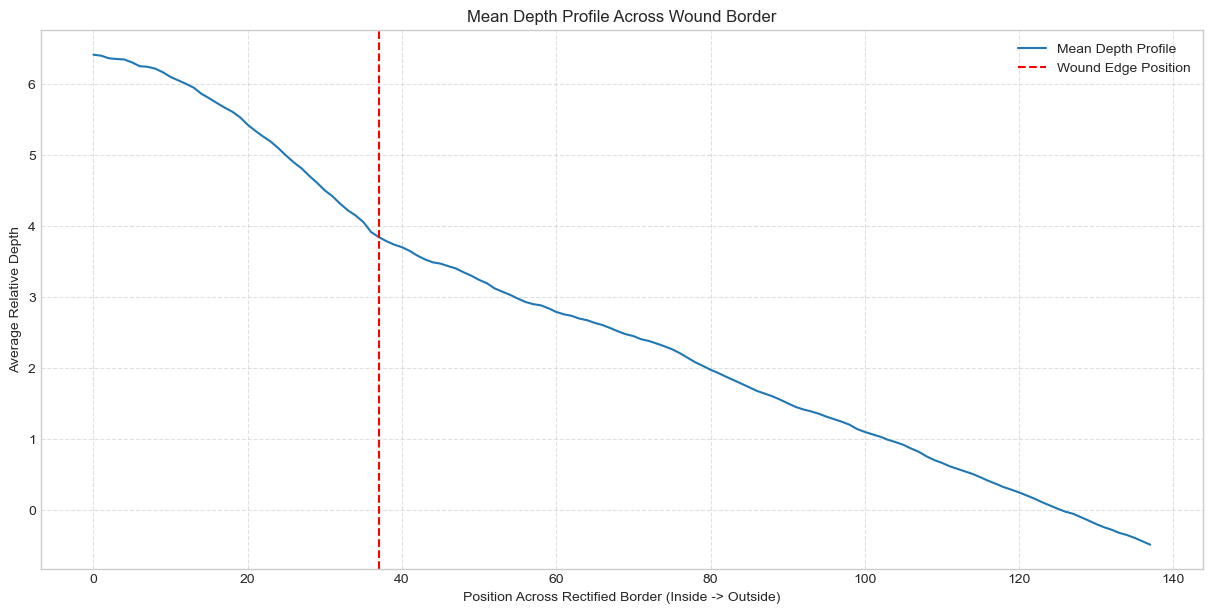

In [79]:
# --- Calculate the Mean Profile ---
# Your `rectify_depth` has shape (transition_steps, perimeter_length).
# We want to average along the perimeter (axis=1) to get the mean transition profile.
# np.nanmean is used to safely ignore any NaN values.
mean_profile = np.nanmean(rect_depth, axis=1)

# --- Visualization ---
plt.figure(figsize=(15, 7))

# Plot the calculated mean profile
plt.plot(mean_profile, label='Mean Depth Profile')

# Add a vertical line at the original wound edge position.
# 's1' from your rectification code marks this boundary.
plt.axvline(x=d1, color='red', linestyle='--', label='Wound Edge Position')

# --- Formatting the Plot ---
plt.title("Mean Depth Profile Across Wound Border")
plt.xlabel("Position Across Rectified Border (Inside -> Outside)")
plt.ylabel("Average Relative Depth")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Mean Depth Profile of Unrolled Depth Strip

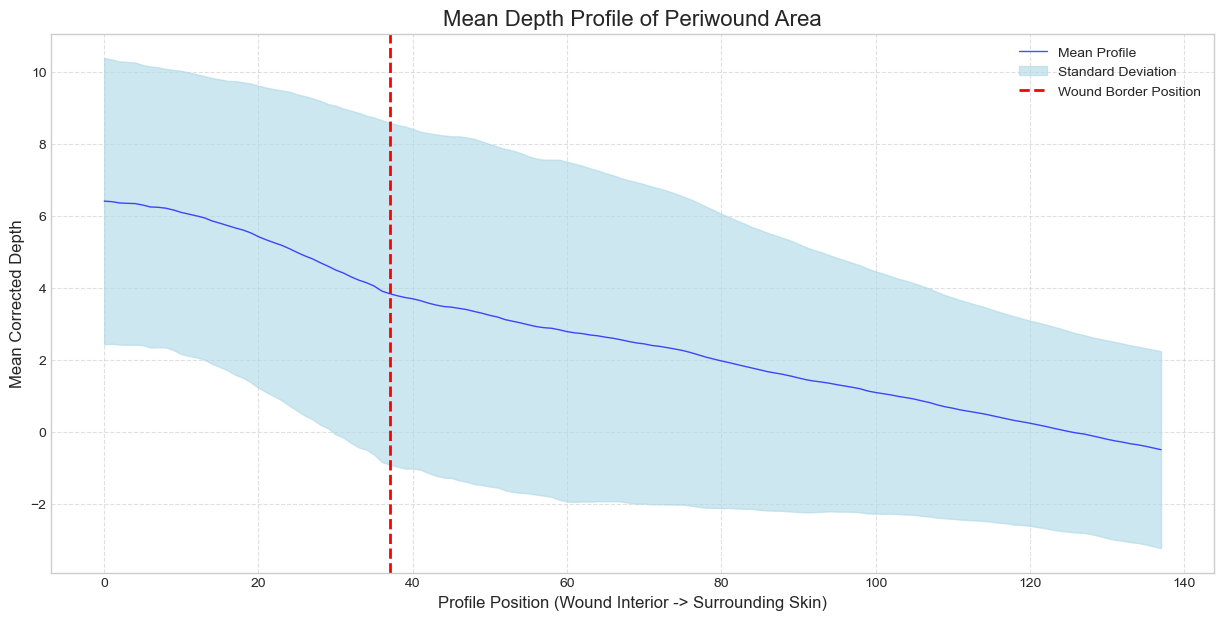

In [80]:

# The `rect_depth` image has a shape of (number_of_strips, contour_height).
# We want to find the average depth for each strip, so we calculate the mean
# along axis 1 (the height of the unrolled image).

mean_profile = np.nanmean(rect_depth, axis=1)
std_profile = np.nanstd(rect_depth, axis=1)

plt.figure(figsize=(15, 7))
plt.plot(mean_profile, color='blue', linewidth=1, alpha=0.7, label='Mean Profile')  

# Add the standard deviation as a shaded area around the mean.
# This gives a great visual indication of how much the depth varies along the contour.
plt.fill_between(range(len(mean_profile)),
                     mean_profile - std_profile,
                     mean_profile + std_profile,
                     color='lightblue', alpha=0.6, label='Standard Deviation')

# Add a vertical line at the position of the wound border.
plt.axvline(x=d1, color='red', linestyle='--', linewidth=2, label='Wound Border Position')
    
plt.title('Mean Depth Profile of Periwound Area', fontsize=16)
plt.xlabel('Profile Position (Wound Interior -> Surrounding Skin)', fontsize=12)
plt.ylabel('Mean Corrected Depth', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


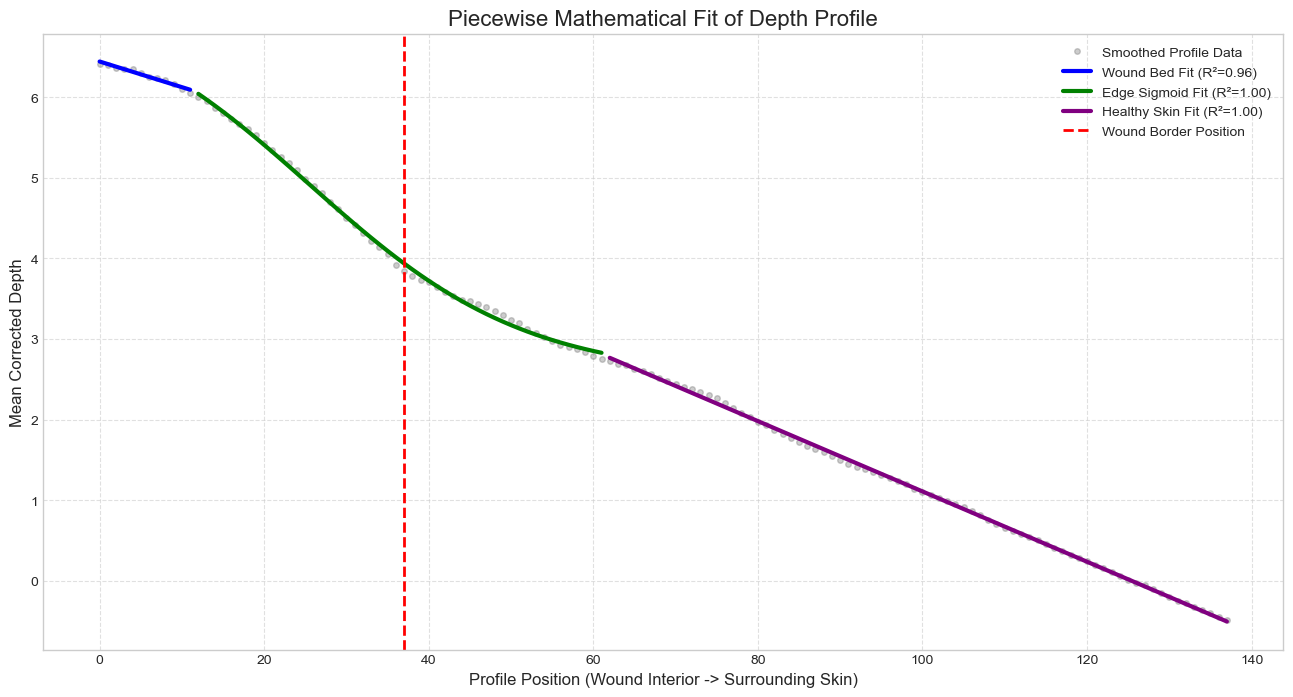


--- Comprehensive Feature Vector ---
bed_slope            -0.031818
bed_intercept         6.442361
bed_r2                0.956874
bed_fit_success       1.000000
edge_amplitude       -4.778191
edge_steepness        0.075711
edge_midpoint        25.548276
edge_offset           7.302491
edge_r2               0.998059
edge_fit_success      1.000000
skin_slope           -0.043607
skin_intercept        5.471028
skin_r2               0.999388
skin_fit_success      1.000000
bed_mean              6.267361
bed_std               0.112287
bed_skew             -0.505143
bed_kurtosis         -0.885597
edge_mean             4.160702
edge_std              1.015719
edge_skew             0.350837
edge_kurtosis        -1.238995
skin_mean             1.132089
skin_std              0.956927
skin_skew             0.023009
skin_kurtosis        -1.200363
spectral_centroid     0.001407
spectral_entropy      0.247356
dtype: float64


In [81]:
from scipy.optimize import curve_fit
from scipy.stats import skew, kurtosis

# Mathematical functions for fitting and feature extraction
# Define the R-squared function to evaluate the fit quality
def r_squared(y_true, y_pred):
    """Calculates the R-squared (coefficient of determination) value."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) if ss_tot > 0 else 0

# Define function for linear fitting
def linear_func(x, m, c):
    """A simple linear function."""
    return m * x + c

# Define function for sigmoid fitting
def sigmoid_func(x, L, k, x0, offset):
    """A generalized logistic (sigmoid) function."""
    return L / (1 + np.exp(-k * (x - x0))) + offset

# Define a function to calculate spectral features
# such as spectral centroid and spectral entropy from a 1D profile segment.
# These features can help in understanding the frequency characteristics of the profile.
def get_spectral_features(profile_segment):
    """Calculates spectral features from a 1D profile segment."""
    n = len(profile_segment)
    if n < 2: return {'spectral_centroid': np.nan, 'spectral_entropy': np.nan}
    fft_vals = np.fft.fft(profile_segment)
    power_spectrum = np.abs(fft_vals[:n // 2]) ** 2
    freqs = np.fft.fftfreq(n, d=1)[:n // 2]
    centroid = np.sum(freqs * power_spectrum) / np.sum(power_spectrum) if np.sum(power_spectrum) > 0 else 0.0
    norm_power = power_spectrum / np.sum(power_spectrum) if np.sum(power_spectrum) > 0 else np.zeros_like(power_spectrum)
    entropy = -np.sum(norm_power * np.log2(norm_power + 1e-9))
    return {'spectral_centroid': centroid, 'spectral_entropy': entropy}

# --- Main Feature Extraction Logic ---

# Initialize a dictionary to store all our extracted features
features = {}

# Divide the profile into three regions using 'd1' as the wound edge position.
transition_width = 50

# Region 1: Wound Bed
end_bed = max(0, d1 - transition_width // 2)
x_bed, y_bed = np.arange(0, end_bed), mean_profile[0:end_bed]

# Region 2: Transitional Edge
start_edge = end_bed
end_edge = min(len(mean_profile), d1 + transition_width // 2)
x_edge, y_edge = np.arange(start_edge, end_edge), mean_profile[start_edge:end_edge]

# Region 3: Healthy Skin
start_skin = end_edge
x_skin, y_skin = np.arange(start_skin, len(mean_profile)), mean_profile[start_skin:]

# Perform Piecewise Fitting 
try:
    params, _ = curve_fit(linear_func, x_bed, y_bed)
    features.update({'bed_slope': params[0], 
                     'bed_intercept': params[1], 
                     'bed_r2': r_squared(y_bed, linear_func(x_bed, *params)), 
                     'bed_fit_success': 1})
except (RuntimeError, TypeError):
    features.update({'bed_slope': np.nan, 
                     'bed_intercept': np.nan, 
                     'bed_r2': np.nan, 
                     'bed_fit_success': 0})

try:
    p0 = [np.max(y_edge)-np.min(y_edge), 0.5, np.mean(x_edge), np.min(y_edge)]
    params, _ = curve_fit(sigmoid_func, x_edge, y_edge, p0=p0, maxfev=10000)
    features.update({'edge_amplitude': params[0], 
                     'edge_steepness': params[1], 
                     'edge_midpoint': params[2], 
                     'edge_offset': params[3], 
                     'edge_r2': r_squared(y_edge, sigmoid_func(x_edge, *params)), 
                     'edge_fit_success': 1})
except (RuntimeError, TypeError):
    features.update({'edge_amplitude': np.nan, 
                     'edge_steepness': np.nan, 
                     'edge_midpoint': np.nan, 
                     'edge_offset': np.nan, 
                     'edge_r2': np.nan, 
                     'edge_fit_success': 0})

try:
    params, _ = curve_fit(linear_func, x_skin, y_skin)
    features.update({'skin_slope': params[0], 
                     'skin_intercept': params[1], 
                     'skin_r2': r_squared(y_skin, linear_func(x_skin, *params)), 
                     'skin_fit_success': 1})
except (RuntimeError, TypeError):
    features.update({'skin_slope': np.nan, 
                     'skin_intercept': np.nan, 
                     'skin_r2': np.nan, 
                     'skin_fit_success': 0})

# Extract Features
if len(y_bed) > 0: features.update({'bed_mean': np.mean(y_bed), 
                                    'bed_std': np.std(y_bed), 
                                    'bed_skew': skew(y_bed), 
                                    'bed_kurtosis': kurtosis(y_bed)})
if len(y_edge) > 0: features.update({'edge_mean': np.mean(y_edge), 
                                     'edge_std': np.std(y_edge), 
                                     'edge_skew': skew(y_edge), 
                                     'edge_kurtosis': kurtosis(y_edge)})
if len(y_skin) > 0: features.update({'skin_mean': np.mean(y_skin), 
                                     'skin_std': np.std(y_skin), 
                                     'skin_skew': skew(y_skin), 
                                     'skin_kurtosis': kurtosis(y_skin)})
if len(y_edge) > 0: features.update(get_spectral_features(y_edge))

# ---Visualize the Fits
plt.figure(figsize=(16, 8))
plt.plot(mean_profile, 'o', color='gray', alpha=0.4, markersize=4, label='Smoothed Profile Data')

if features['bed_fit_success']:
    params_bed = [features['bed_slope'], features['bed_intercept']]
    plt.plot(x_bed, linear_func(x_bed, *params_bed), 
             color='blue', 
             linewidth=3, 
             label=f"Wound Bed Fit (R²={features['bed_r2']:.2f})")

if features['edge_fit_success']:
    params_edge = [features['edge_amplitude'], 
                   features['edge_steepness'], 
                   features['edge_midpoint'], 
                   features['edge_offset']]
    plt.plot(x_edge, sigmoid_func(x_edge, *params_edge), 
             color='green', 
             linewidth=3, 
             label=f"Edge Sigmoid Fit (R²={features['edge_r2']:.2f})")

if features['skin_fit_success']:
    params_skin = [features['skin_slope'], features['skin_intercept']]
    plt.plot(x_skin, linear_func(x_skin, *params_skin), 
             color='purple', 
             linewidth=3, 
             label=f"Healthy Skin Fit (R²={features['skin_r2']:.2f})")

plt.axvline(x=d1, color='red', linestyle='--', linewidth=2, label='Wound Border Position')
plt.title('Piecewise Mathematical Fit of Depth Profile', fontsize=16)
plt.xlabel('Profile Position (Wound Interior -> Surrounding Skin)', fontsize=12)
plt.ylabel('Mean Corrected Depth', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#  Display the Final Feature Vector ---
feature_series = pd.Series(features)
print("\n--- Comprehensive Feature Vector ---")
print(feature_series)
